# Energy Spectral Density (ESD)



The **Energy Spectral Density (ESD)** describes how the energy of an **energy signal** is distributed across frequency.

### Definition

$
\Psi_x(f)=|X(f)|^2
$

where \(X(f)\) is the Fourier Transform of \(x(t)\).

### Total Energy (Parseval's Theorem)

$
E=\int_{-\infty}^{\infty}|x(t)|^2\,dt
=\int_{-\infty}^{\infty}\Psi_x(f)\,df
$

### Wiener–Khinchin Theorem

The ESD is the Fourier Transform of the autocorrelation function:

$
\Psi_x(f)=\mathcal{F}\{R_{xx}(\tau)\}
$

where

$
R_{xx}(\tau)=\int_{-\infty}^{\infty}x(t)x^*(t-\tau)\,dt.
$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import scienceplots 

plt.style.use(['science','no-latex'])


In [13]:
a=sp.symbols('a',real=True,positive=True)
t,f=sp.symbols('t f',real=True)
tau=sp.symbols('tau',real=True)

Example:

$x(t)=e^{-at}u(t)$

In [14]:
#finding its energy
x=sp.exp(-a*t)*sp.Heaviside(t)
Ex=sp.integrate(x**2,(t,-sp.oo,sp.oo))

In [15]:
Ex

1/(2*a)

In [21]:
#using Energy spectral Density to detemine the energy
xd=x.subs(t,t-tau) # delayed signal
Rxx=sp.integrate(x*xd,(t,-sp.oo,sp.oo))
Rxx

Piecewise((exp(a*tau)/(2*a), (tau < 0) & Eq(arg(tau) - pi, 0)), (Integral(exp(-a*t)*exp(-a*(t - tau))*Heaviside(t)*Heaviside(t - tau), (t, -oo, oo)), True))

In [32]:
#Using Energy spectral density method

X=sp.fourier_transform(x,t,f)
ESD=(sp.Abs(X))**2
ESD

1/(a**2 + 4*pi**2*f**2)

In [30]:
#Find the inverse fourier transform of ESD
esd=sp.inverse_fourier_transform(ESD,f,t)
esd

exp(-a*t)/(2*a)

In [31]:
esd.subs(t,0)

1/(2*a)

Text(0.5, 1.0, 'ESD')

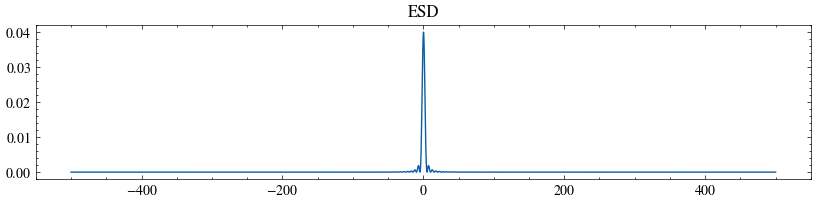

In [39]:
import numpy as np
from scipy . fft import fft , fftshift
from scipy . signal import welch
import matplotlib . pyplot as plt
# 1. Setup Time and Signals
Fs = 1000; 
t = np . arange (0 , 2, 1/ Fs )
pulse = np . where ( np . abs (t -1) < 0.1 , 1.0 , 0.0)
noise = np . sin (2* np . pi *50* t) + np . random . randn ( len (t ))
# 2. ESD Computation ( using FFT )
# ESD = | X ( f )|^2
X = fftshift ( fft ( pulse )) / Fs
f_esd = np . linspace ( - Fs /2 , Fs /2 , len (t ))
ESD = np . abs (X )**2
# 3. PSD Computation ( Welch ’s Method )
# Averages overlapping periodograms to smooth noise
f_psd , PSD = welch ( noise , Fs , nperseg =256)
# Plotting Commands ( Conceptual )
plt.figure(figsize=(10,2))
plt . plot ( f_esd , ESD );
plt . title ( 'ESD')
#plt . semilogy ( f_psd , PSD );plt . title ( 'PSD ')

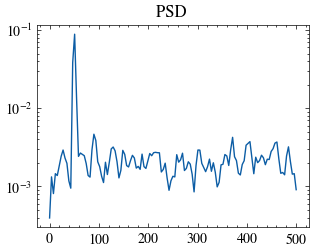

In [45]:
plt . semilogy ( f_psd , PSD );
plt . title ( 'PSD ')
plt.show()

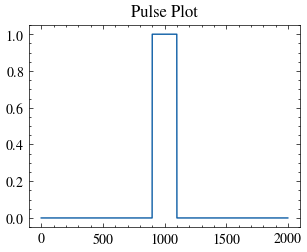

In [43]:
plt.plot(pulse)
plt.title("Pulse Plot")
plt.show()